# Project 1 - Supermarket Sales Analysis

**Domain:** Retail  
**Period:** January-March 2024  
**Goal:** Turn transaction data into inventory, promotion, and customer-retention recommendations.

## 1. Setup and data loading

In [1]:
from pathlib import Path
import sys, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT = Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.sales_analysis import validate_sales_data, clean_sales_data, calculate_kpis
raw = pd.read_csv(ROOT/'data/project1_sales/supermarket_sales_raw.csv')
raw.head()

,invoice_id,date,time,branch,city,customer_type,gender,category,product,unit_price,quantity,discount_pct,payment_method,rating,cost_price
0,INV-2024-00001,2024-03-13,14:40,C,Bengaluru,Normal,Male,Electronics,Smart Watch,4278.65,5,0.00,UPI,6.9,2952.27
1,INV-2024-00002,2024-02-12,19:07,A,Delhi,Member,Female,Groceries,Breakfast Cereal,359.52,3,0.00,Card,9.3,294.81
2,INV-2024-00003,2024-03-20,19:09,C,Bengaluru,Normal,Female,Sports,Dumbbell Set,2554.66,3,0.10,Cash,8.4,1634.98
3,INV-2024-00004,2024-03-06,17:46,A,Delhi,Member,Female,Clothing,T-Shirt,767.02,2,0.05,Cash,7.9,467.88
4,INV-2024-00005,2024-01-10,16:19,A,Delhi,Normal,Female,Electronics,Smart Watch,3861.58,5,0.10,UPI,8.9,2664.49


## 2. Data validation and quality assessment

We check schema completeness, duplicates, missing values, and valid numeric ranges before analysis.

In [2]:
raw_validation = validate_sales_data(raw)
pd.Series(raw_validation)

rows                                 2502
columns                                15
missing_required_columns               []
duplicate_invoice_ids                   2
missing_values              {'rating': 4}
invalid_quantity_rows                   0
invalid_price_rows                      0
invalid_discount_rows                   0
invalid_rating_rows                     4
dtype: object

## 3. Cleaning and feature engineering

In [3]:
sales = clean_sales_data(raw)
clean_validation = validate_sales_data(sales)
print(f'Rows: {len(raw):,} raw -> {len(sales):,} cleaned')
sales[['gross_sales','discount_amount','net_sales','profit','profit_margin_pct']].head()

Rows: 2,502 raw -> 2,500 cleaned


,gross_sales,discount_amount,net_sales,profit,profit_margin_pct
0,2797.26,0.000,2797.260,1090.930,38.999950
1,2101.56,0.000,2101.560,651.480,30.999829
2,3053.19,305.319,2747.871,732.771,26.666863
3,17584.90,879.245,16705.655,5099.605,30.526220
4,3907.00,781.400,3125.600,-78.160,-2.500640


## 4. Descriptive statistics and headline KPIs

In [4]:
kpis = calculate_kpis(sales)
pd.Series(kpis).to_frame('Value')

,Value
total_sales,10035919.4
total_profit,2820498.65
transactions,2500
average_transaction_value,4014.37
median_transaction_value,2765.62
average_rating,7.6
overall_profit_margin_pct,28.1
best_category,Electronics
best_category_sales,3478248.33
best_weekday,Saturday


In [5]:
sales[['unit_price','quantity','discount_pct','rating','net_sales','profit']].describe().round(2)

,unit_price,quantity,discount_pct,rating,net_sales,profit
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1658.77,2.64,0.07,7.60,4014.37,1128.20
std,1027.19,1.43,0.06,1.25,3537.37,1153.60
min,349.75,1.00,0.00,3.20,307.12,-101.30
25%,793.33,1.00,0.00,6.70,1531.69,292.39
50%,1418.33,2.00,0.05,7.60,2765.62,730.36
75%,2412.43,4.00,0.10,8.50,5483.07,1620.65
max,4310.85,7.00,0.20,10.00,23820.96,7384.50


## 5. Category and product performance

In [6]:
category_summary = sales.groupby('category').agg(transactions=('invoice_id','count'), units=('quantity','sum'), revenue=('net_sales','sum'), profit=('profit','sum')).assign(margin_pct=lambda x:x.profit/x.revenue*100).sort_values('revenue',ascending=False)
category_summary.round(2)

,transactions,units,revenue,profit,margin_pct
category,,,,,
Electronics,544,1416,3478248.33,914273.73,26.29
Clothing,487,1236,2312025.18,793621.99,34.33
Home & Kitchen,307,796,1325026.34,384651.16,29.03
Groceries,657,1877,1184085.89,137648.80,11.62
Sports,230,612,940271.79,289000.11,30.74
Personal Care,275,675,796261.87,301302.86,37.84


In [7]:
product_summary = sales.groupby(['category','product']).agg(units=('quantity','sum'),revenue=('net_sales','sum'),profit=('profit','sum')).sort_values('revenue',ascending=False)
product_summary.head(10).round(2)

units     revenue     profit
category       product                                        
Electronics    Smart Watch          355  1330016.41  354173.33
Clothing       Jacket               356   990834.83  339674.02
Electronics    Bluetooth Speaker    330   868879.22  226223.52
               Earbuds              391   804751.26  210338.41
Home & Kitchen Mixer Grinder        205   630404.57  186839.76
Clothing       Sports Shoes         260   607626.78  209600.57
Electronics    Power Bank           340   474601.44  123538.47
Clothing       Jeans                273   455622.19  156005.93
Groceries      Dry Fruits           453   402168.37   50126.82
               Cooking Oil          513   376080.05   42674.12

## 6. Customer, time, and branch analysis

In [8]:
sales.groupby('customer_type').agg(transactions=('invoice_id','count'),average_spend=('net_sales','mean'),average_rating=('rating','mean'),revenue=('net_sales','sum')).round(2)

,transactions,average_spend,average_rating,revenue
customer_type,,,,
Member,1140,3917.20,7.72,4465612.68
Normal,1360,4095.81,7.50,5570306.73


In [9]:
sales.groupby(['branch','city']).agg(transactions=('invoice_id','count'),revenue=('net_sales','sum'),profit=('profit','sum')).sort_values('revenue',ascending=False).round(2)

,,transactions,revenue,profit
branch,city,,,
A,Delhi,972,3940839.27,1111715.75
B,Mumbai,839,3289392.49,919690.12
C,Bengaluru,689,2805687.65,789092.79


In [10]:
sales.groupby('weekday')['net_sales'].agg(['count','mean','sum']).sort_values('sum',ascending=False).round(2)

,count,mean,sum
weekday,,,
Saturday,441,4161.21,1835093.68
Sunday,415,4127.50,1712914.46
Tuesday,333,4035.30,1343756.01
Wednesday,332,4012.38,1332109.73
Monday,320,4106.63,1314120.58
Friday,328,3899.18,1278929.66
Thursday,331,3682.77,1218995.28


## 7. Correlation analysis

Pearson correlation measures linear association; it does not prove causation.

In [11]:
corr = sales[['unit_price','quantity','discount_pct','rating','net_sales','profit']].corr().round(3)
corr

,unit_price,quantity,discount_pct,rating,net_sales,profit
unit_price,1.000,-0.052,-0.029,0.041,0.687,0.664
quantity,-0.052,1.000,-0.020,0.028,0.572,0.486
discount_pct,-0.029,-0.020,1.000,0.013,-0.115,-0.260
rating,0.041,0.028,0.013,1.000,0.041,0.030
net_sales,0.687,0.572,-0.115,0.041,1.000,0.950
profit,0.664,0.486,-0.260,0.030,0.950,1.000


## 8. Visualizations

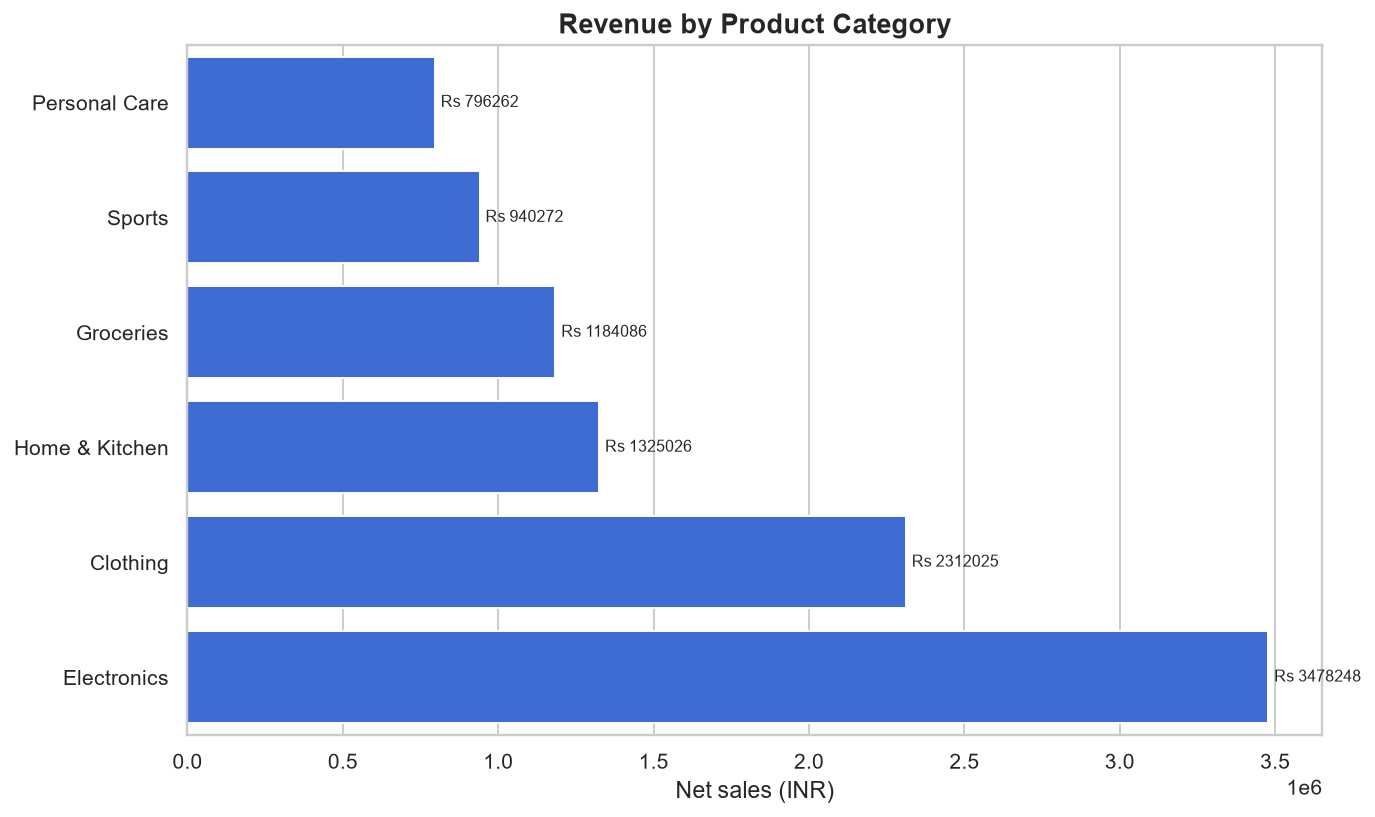

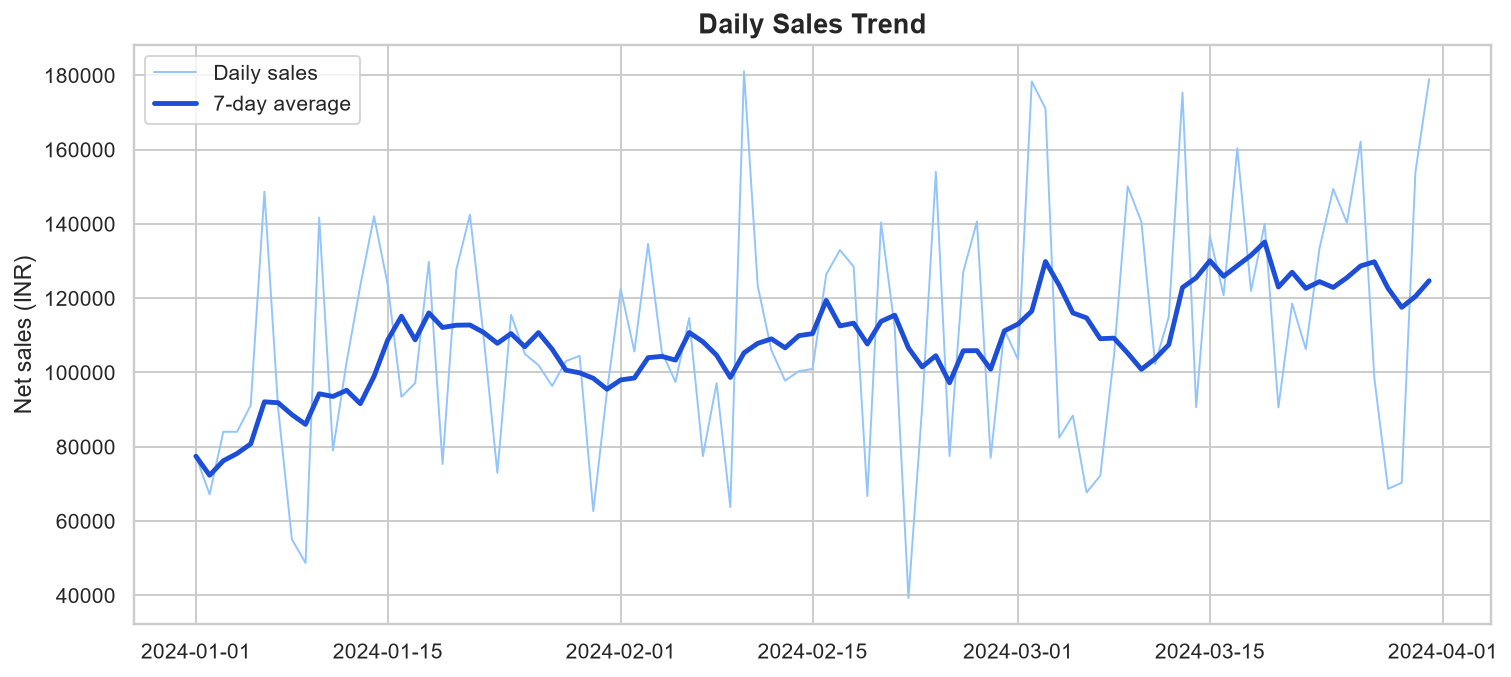

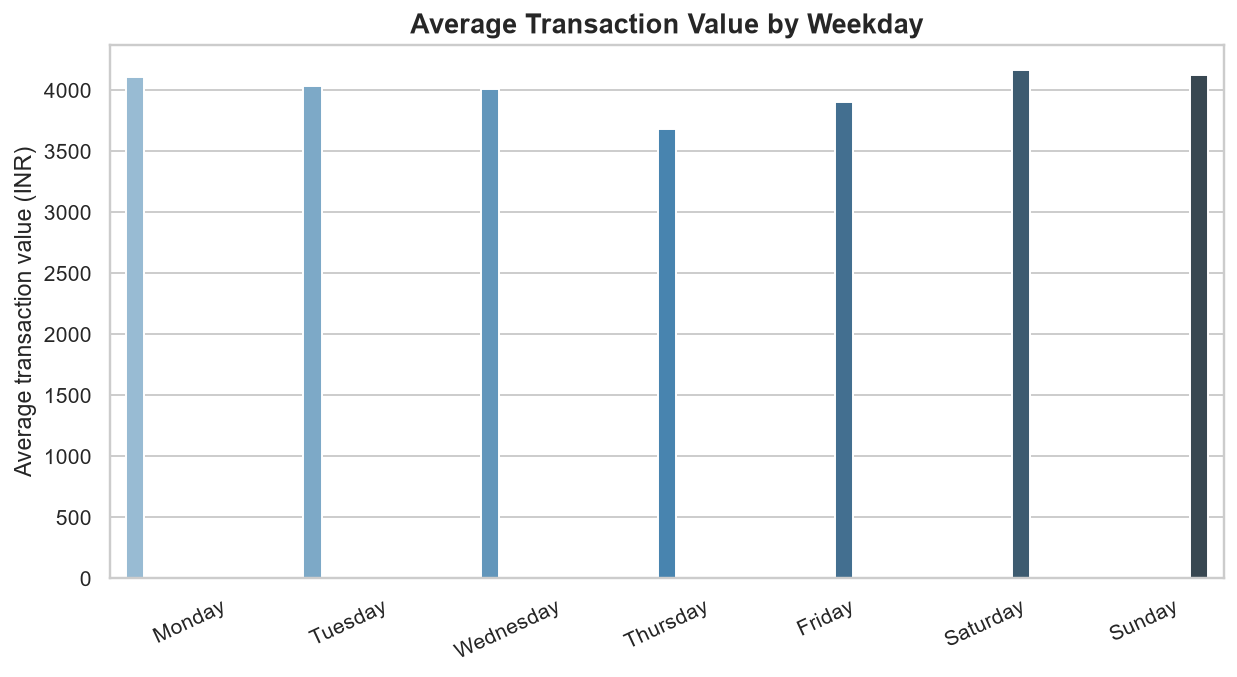

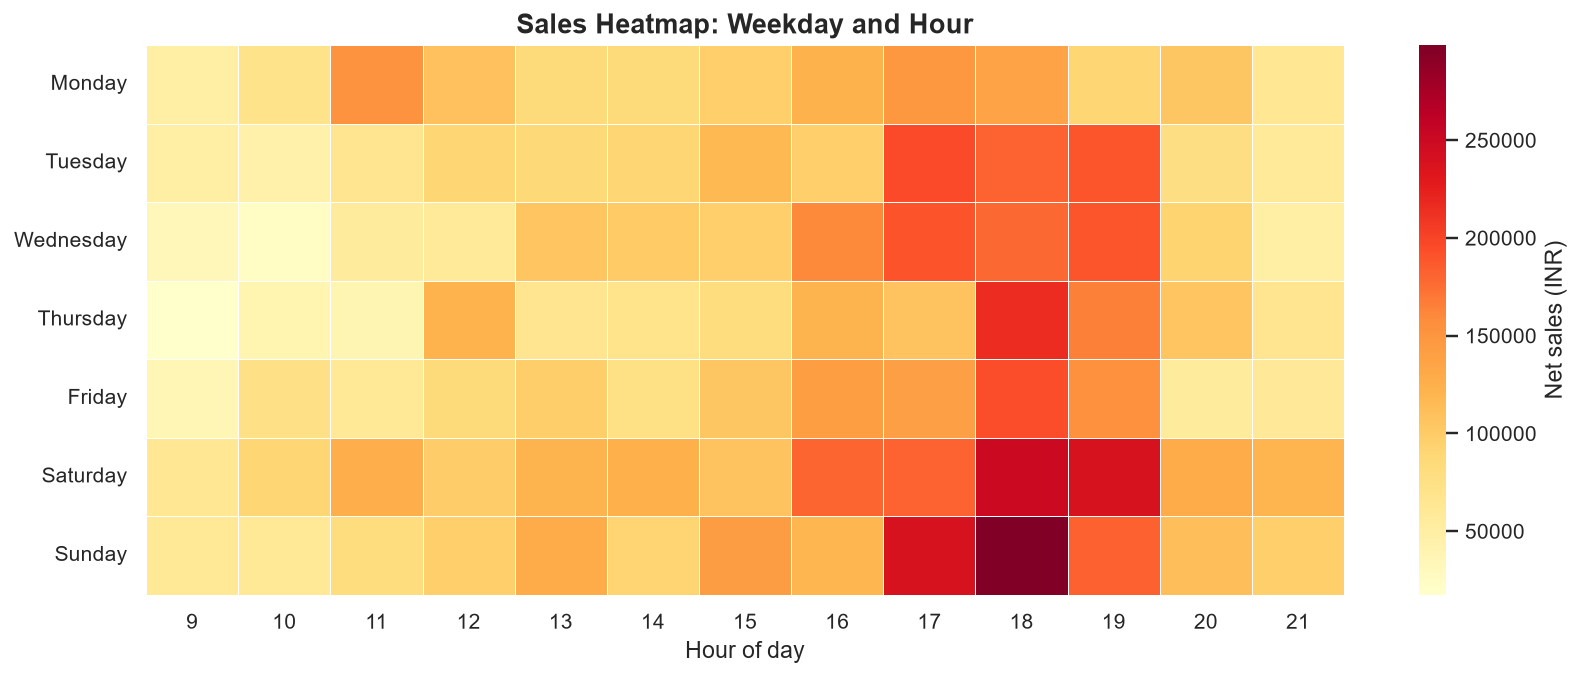

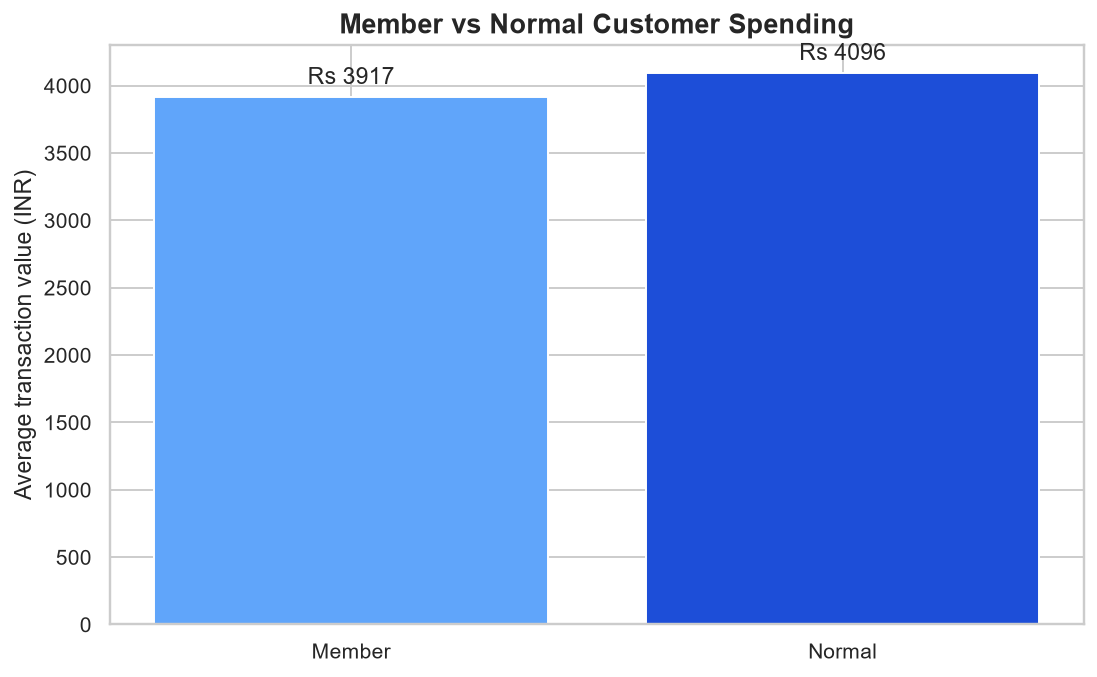

In [12]:
from IPython.display import display, Image
for chart in sorted((ROOT/'visualizations/project1_sales').glob('*.png')):
    display(Image(filename=str(chart), width=850))

## 9. Business insights and recommendations

1. Prioritize replenishment for the highest-revenue categories while monitoring margin, not revenue alone.
2. Schedule staffing and promotional activity around evening and weekend demand.
3. Use member-exclusive bundles to increase repeat purchasing without relying on blanket discounts.
4. Protect high-margin categories through targeted cross-selling.
5. Validate recommendations with branch-level A/B tests because this simulated analysis is observational.

## 10. Conclusion

The workflow converts raw transaction records into validated data, statistical evidence, clear visuals, and testable retail actions. See the PDF report for the executive presentation.